# Contamination-aware differential gene expression analysis

## Issue of spill-over effects in imaging-based spatial transcriptomics methods

Imaging-based spatial transcriptomics methods such as Xenium In Situ enable the measurement of RNA at single-molecule resolution. To assign transcripts to individual cells, these methods rely on cell segmentation algorithms. However, due to the complex nature of biological tissues, including densely packed cells, irregular cell shapes, and variable staining intensities, cell segmentation is often challenging, leading to inaccurately drawn cell boundaries. This can result in spill-over effects, where transcripts from one cell are incorrectly assigned to neighboring cells. Consequently, when performing differential gene expression analysis, one cannot always confidently determine whether detected genes were genuinely upregulated in the cells of interest or merely reflected transcript misassignment from adjacent cells. This issue is particularly problematic in regions with closely apposed cell membranes or when analyzing rare cell types surrounded by cells with distinct expression profiles. To mitigate these effects, we recommend comparing target and reference cell populations both against each other and against their respective neighborhoods, thereby distinguishing genuine expression changes from neighborhood-driven spill-over artifacts.

In [1]:
## The following code ensures that all functions and init files are reloaded before executions.
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from insitupy import InSituData, CACHE

## Load Xenium data into `InSituData` object

Now the Xenium data can be parsed by providing the data path to the `InSituPy` project folder.

In [3]:
insitupy_project = Path(CACHE / "out/demo_insitupy_project")

In [4]:
xd = InSituData.read(insitupy_project)

In [5]:
xd.load_images()
xd.load_cells()
xd.load_annotations()

In [6]:
from insitupy.tools.neighbors import mean_gex_diff_to_neighbors, max_gex_diff_to_neighbors

In [7]:
adata = xd.cells.matrix.copy()

In [8]:
results, adj, diffs, qc = mean_gex_diff_to_neighbors(
    adata=adata, celltype_tuple=("cell_type_dc_sub_final", "Stromal cells"),
    radius=20
)

Building spatial graph (radius=20, weighted=False)...
Selected 21022 'Stromal cells' cells as targets
Excluding same-celltype neighbors from adjacency matrix...
Computing mean neighbor expression...
Computing gex_diff = gex_target - gex_neighbor ...
Running paired tests (wilcoxon) per gene and computing effect sizes...


genes: 100%|██████████| 297/297 [00:07<00:00, 39.61it/s]


Applying multiple-testing correction...

ANALYSIS SUMMARY
Target cell type: 'Stromal cells'
Target cells: 21022/156447 (13.4%)
Genes tested: 297
Target cells without neighbors: 0 (0.0%)
Median neighbors per target cell: 2.0



Look into gene expression differences on a cellular level:

In [ ]:
# select the gene that is most likely contaminated
gene = results.sort_values("contamination_score", ascending=False).index[0]
adata.obs[f"contamination_{gene}"] = diffs[:, adata.var_names.get_loc(gene)]

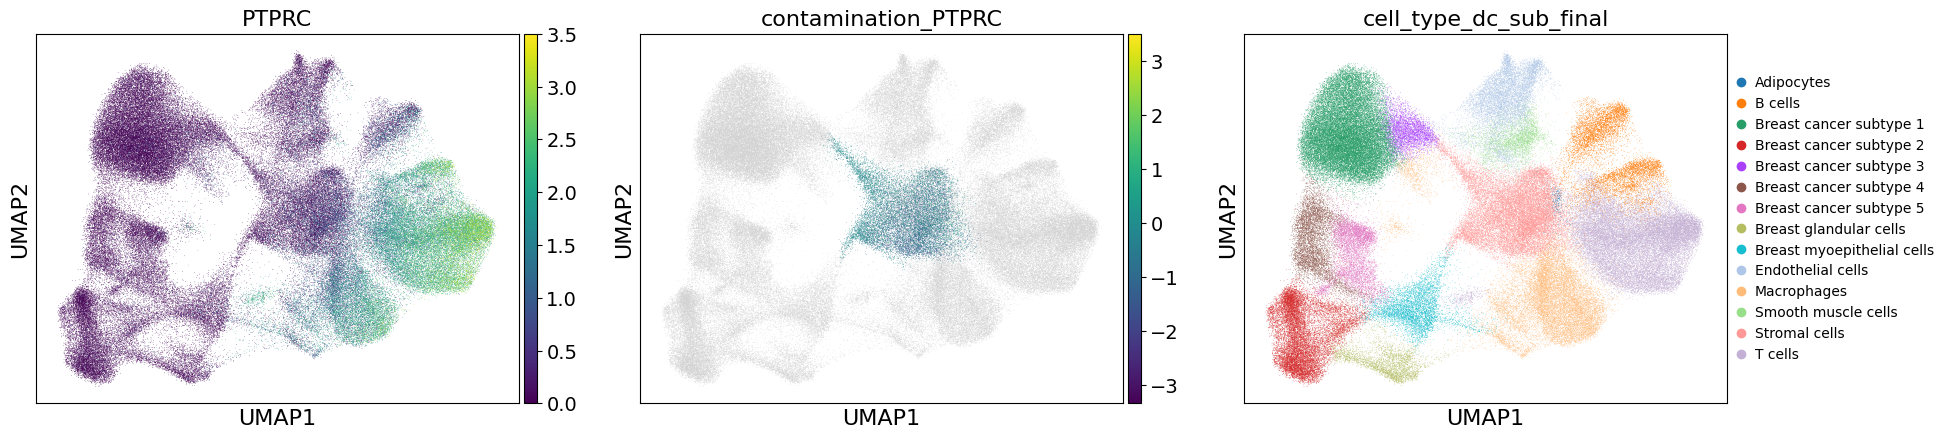

In [ ]:
import scanpy as sc
sc.pl.umap(adata, color=[gene, f"contamination_{gene}", "cell_type_dc_sub_final"], vmax=3.5)

### Determine null distribution for each gene

To better understand the meaning of the gene expression differences, we will use here a permutation test to estimate what gene expression differences we would expect under random circumstances.

In [11]:
from insitupy.tools.permutation import permutation_test_mean_gex_diff, quick_permutation_summary

# First run the observed analysis
results_obs, A_ct, gex_diff, qc = mean_gex_diff_to_neighbors(
    adata, radius=20, celltype_tuple=("cell_type_dc_sub_final", "Stromal cells")
)

# Then run permutation test
results_perm = permutation_test_mean_gex_diff(
    adata,
    observed_results=results_obs,
    radius=20,
    celltype_tuple=("cell_type_dc_sub_final", "Stromal cells"),
    n_permutations=100,
    #genes_to_test=["PTPRC"],
    n_jobs=-1  # use all cores
)

# View summary
quick_permutation_summary(results_perm)

Building spatial graph (radius=20, weighted=False)...
Selected 21022 'Stromal cells' cells as targets
Excluding same-celltype neighbors from adjacency matrix...
Computing mean neighbor expression...
Computing gex_diff = gex_target - gex_neighbor ...
Running paired tests (wilcoxon) per gene and computing effect sizes...


genes: 100%|██████████| 297/297 [00:09<00:00, 32.14it/s]


Applying multiple-testing correction...

ANALYSIS SUMMARY
Target cell type: 'Stromal cells'
Target cells: 21022/156447 (13.4%)
Genes tested: 297
Target cells without neighbors: 0 (0.0%)
Median neighbors per target cell: 2.0

Running permutation test with 100 permutations...
Using all 16 cores for parallel processing
Pre-computing base spatial graph...
Base graph computed: 1173982 edges for 156447 cells
Running permutations...


Permutations: 100%|██████████| 100/100 [01:49<00:00,  1.09s/perm]

Computing empirical p-values...

Permutation test complete!
Genes tested: 297/297
Significant genes (FDR < 0.05): 277/297
Mean null distribution mean: 0.0017
Mean null distribution std: 0.0032

PERMUTATION TEST SUMMARY
Total genes: 297
Genes tested: 297
Significant genes (FDR < 0.05): 277 (93.3%)

Top 20 significant genes:
Gene                log2FC     perm_p  perm_padj    z-score
----------------------------------------------------------------------
VOPP1               -0.128     0.0099     0.0106     -26.36
USP53                0.057     0.0099     0.0106      12.35
TYROBP              -0.091     0.0099     0.0106     -35.91
TUBB2B              -0.015     0.0099     0.0106      -5.86
TUBA4A              -0.211     0.0099     0.0106     -46.19
TRIB1               -0.155     0.0099     0.0106     -46.09
TRAF4               -0.035     0.0099     0.0106      -9.73
TRAC                -0.420     0.0099     0.0106     -84.76
TPSAB1               0.032     0.0099     0.0106      16.54
TPD5

In [12]:
from insitupy.tools.permutation import calculate_contamination_threshold

# Usage examples
print("=== CONTAMINATION THRESHOLDS ===\n")

# Get detailed info
details = calculate_contamination_threshold(
    results_perm,
    percentile=95,
    direction="negative",
    return_details=True
)

print(f"Z-score used: {details['z_score']:.3f}")
print(f"Number of genes: {details['n_genes']}")
print(f"Gene threshold range: {details['threshold_range'][0]:.3f} to {details['threshold_range'][1]:.3f}")
print(f"Gene threshold std: {details['threshold_std']:.3f}")
print(f"Global threshold: {details['global_threshold']:.3f}")

=== CONTAMINATION THRESHOLDS ===

Z-score used: -1.645
Number of genes: 297
Gene threshold range: -0.012 to 0.018
Gene threshold std: 0.003
Global threshold: -0.004


## Include the neighborhood contamination info into differential gene expression analysis

In [13]:
from insitupy.tools import dge
dge_results = dge(
    target=xd,
    target_cell_type_tuple=("cell_type_dc_sub_final", "Breast cancer subtype 4"),
    ref_cell_type_tuple=("cell_type_dc_sub_final", "Breast cancer subtype 1"),
    ref=None,
    method="wilcoxon",
    consider_neighbors=True,
    exclude_ambiguous_assignments=True
    )

In [15]:
dge_results.main

,log2foldchange,padj,scores,neg_log10_pvals
gene,,,,
SERPINA3,5.463246,1.000000e-300,101.212189,300.0
CEACAM6,3.637490,1.000000e-300,94.099846,300.0
AGR3,4.773612,1.000000e-300,84.277008,300.0
TACSTD2,1.096257,1.000000e-300,64.926903,300.0
ESR1,2.567329,1.000000e-300,50.270954,300.0
...,...,...,...,...
TCIM,-1.277700,1.000000e-300,-49.620869,300.0
MDM2,-0.940504,1.000000e-300,-50.664825,300.0
FASN,-0.892925,1.000000e-300,-60.591518,300.0


### Plotting of DGE + neighborhood results

If we include the neighborhood information into the DGE analysis, we get results for three different comparisons:
1. Target vs. Reference
2. Target vs. Neighborhood of Target
3. References vs. Neighborhood of Reference

We can plot all three using the `volcano` function:

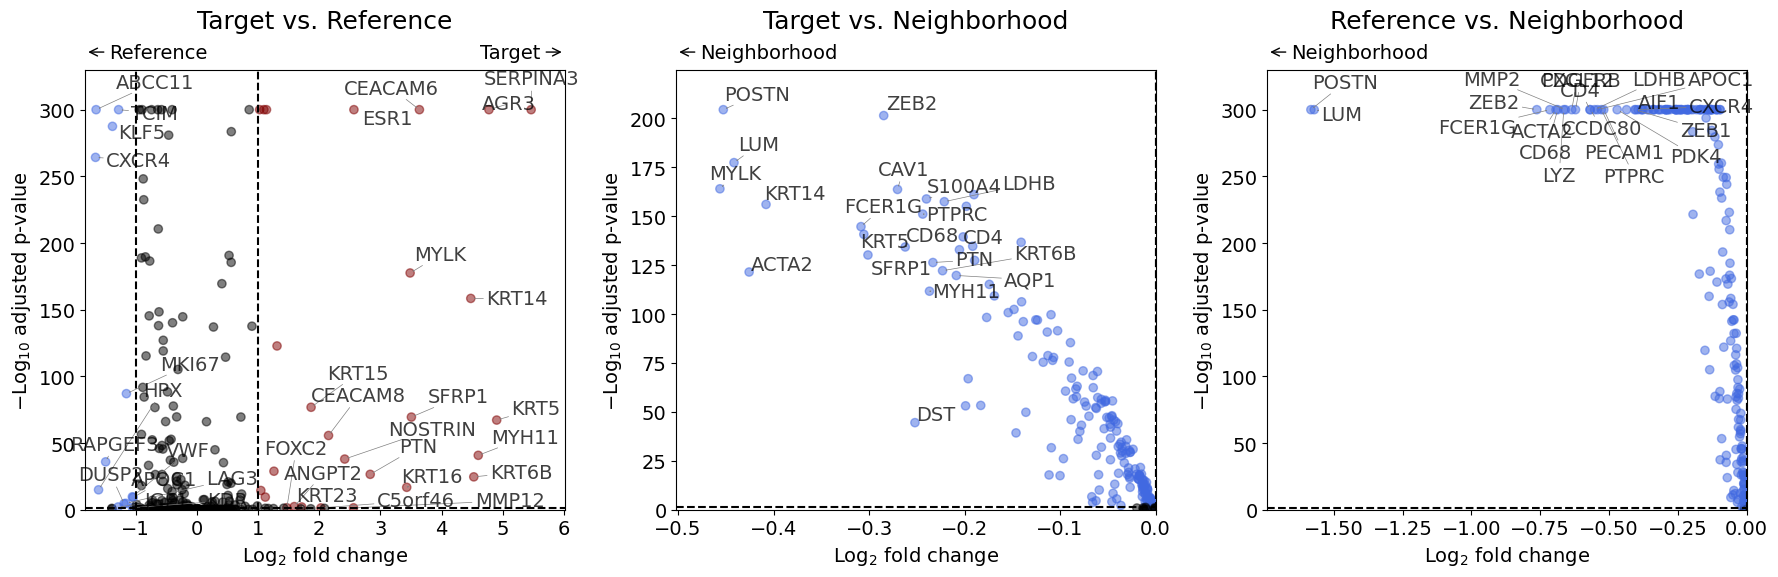

In [20]:
from insitupy.plotting import dual_foldchange_plot, volcano
volcano(dge_results)

Or we can combine the results using the `dual_foldchange_plot`. This consists of two plots:
1. Plot "Downregulated":
    - X-Axis: log2foldchanges of target vs. reference, showing which genes are higher expressed in the reference.
    - Y-Axis: log2foldchanges of t
contains the information about the fold changes between target and reference

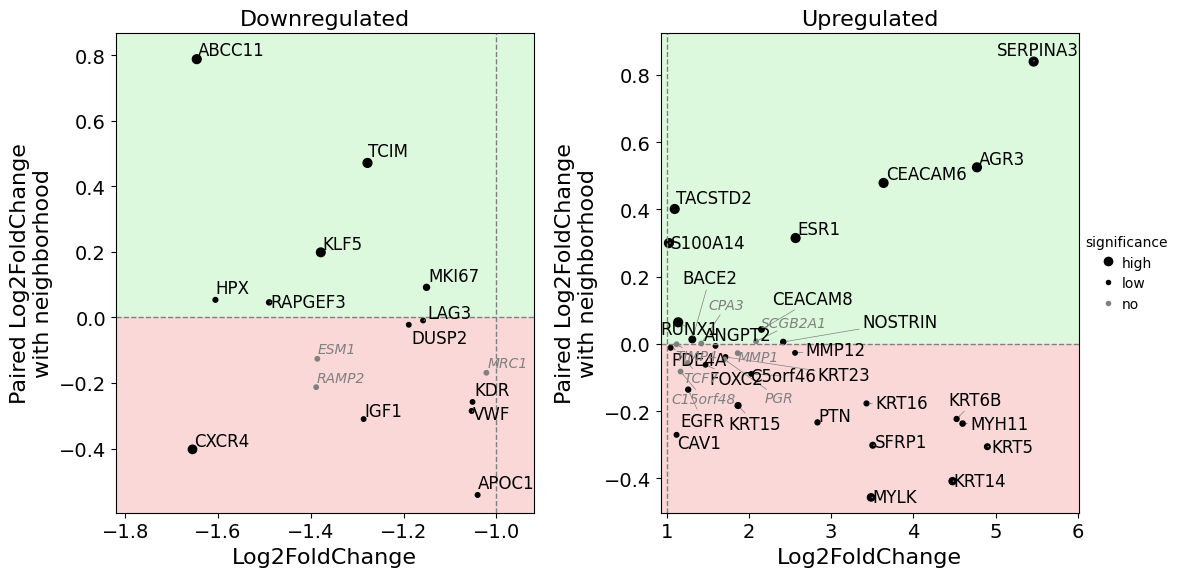

In [30]:
dual_foldchange_plot(
    dge_results, foldchange_threshold=2,
    adjust_labels=True,
    size_by_pvalue=True,
    show_nonsignificant=True
    )

## Estimate neighborhood gene expression difference using the maximum gradient

### Determine null distribution for each gene

When calculating the gene expression difference of target cells to their neighborhood, alternatively to taking the mean gene expression in the neighboring cells, one can also determine for each gene the maximum gene expression in the neighborhood and use this to calculate the gene expression. This would reflect more closely the probability of a gene getting contaminated by neighboring genes, since especially a high expression in the neighborhood would contribute to contaminations. However, using this assumption the assumption of having a null distribution centering around 0 is violated. This assumption is important to do the paired statistical tests and get information about the effect size for each gene. Therefore, we have to determine the null distribution here using a permutation test, where we shuffle the target cells and calculate the expected gene expression gradient for randomly positioned target cells.

Here is a further summary on this topic:

Paired DGE analysis between target cells and the maximum expression in the neighborhood. The neighborhood would be defined as the maximum expression of each gene of all (non-target) neighboring cells. Problem here is that the zero distribution is not clear. So one has to do a permutation test, where all the target cells are shuffled (neighboring cells stay the same) and then the mean of the resulting null distribution for each gene is compared against the mean of the observed max expression difference for each gene. The p-value is then the fraction of cases in which the observed mean value shows an even more negative gene expression gradient than the mean of the null distribution (assuming gex_target - gex_nb). The effect size could then be standardized against the null distribution with `standardized_effect = (observed_mean - null_mean) / null_sd`.

In [32]:
from insitupy.tools.neighbors import max_gex_diff_to_neighbors

# First run the observed analysis
results_obs, A_ct, gex_diff, qc = max_gex_diff_to_neighbors(
    adata, radius=20, celltype_tuple=("cell_type_dc_sub_final", "Stromal cells")
)

Building spatial graph (radius=20, weighted=False)...
Selected 21022 'Stromal cells' cells as targets
Excluding same-celltype neighbors from adjacency matrix...
Computing max neighbor expression (per-gene maximum)...


cells: 100%|██████████| 21022/21022 [00:25<00:00, 825.39it/s] 


Computing gex_diff = gex_target - gex_neighbor_max ...
Running paired tests (wilcoxon) per gene and computing effect sizes...


genes: 100%|██████████| 297/297 [00:09<00:00, 31.74it/s]


Applying multiple-testing correction...

ANALYSIS SUMMARY
Target cell type: 'Stromal cells'
Target cells: 21022/156447 (13.4%)
Genes tested: 297
Target cells without neighbors: 0 (0.0%)
Median neighbors per target cell: 2.0



In [33]:
results_obs

,n_target_cells,n_cells_used,n_cells_expressed,mean_target,mean_neighbor_max,log2foldchange,log2foldchange_unpaired,pvalue,padj,contamination_score
gene,,,,,,,,,,
ABCC11,21022,15065,2216,0.145756,0.481699,-0.484663,-1.979555,0.000000e+00,0.000000e+00,1.972135
ACTA2,21022,15065,11534,1.306177,1.710432,-0.583216,-0.751245,0.000000e+00,0.000000e+00,0.414753
ACTG2,21022,15065,9496,0.786381,1.522884,-1.062550,-1.584610,0.000000e+00,0.000000e+00,1.198751
ADAM9,21022,15065,8662,0.663105,1.114731,-0.651558,-1.122768,0.000000e+00,0.000000e+00,0.853825
ADGRE5,21022,15065,3218,0.207064,0.850666,-0.928523,-2.543444,0.000000e+00,0.000000e+00,3.023877
...,...,...,...,...,...,...,...,...,...,...
VWF,21022,15065,2746,0.177604,0.829995,-0.941202,-2.734323,0.000000e+00,0.000000e+00,3.390452
WARS,21022,15065,6303,0.459855,0.999393,-0.778389,-1.555926,0.000000e+00,0.000000e+00,1.390341
ZEB1,21022,15065,8654,0.699699,0.996877,-0.428738,-0.754991,9.546924e-279,1.300659e-278,0.536124


Select a smaller region of interest to speed up the permutation test.

In [67]:
xd.load_regions()

C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,
C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,
C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,
C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,


In [68]:
xd.show()

INFO: New layer '🌍 Region1 (demo_regions)' created.
INFO: New layer '🌍 Region2 (demo_regions)' created.
INFO: New layer '🌍 Region3 (demo_regions)' created.


In [ ]:
xd.regions["demo_regions"]["name"] == "Region3"

id
2d0da635-c408-459f-9178-839097fe5a98    Region1
ce6c2342-620d-4f44-be03-68a4454e9b33    Region2
70a125ec-c53e-469b-8927-efe224e504c1    Region3
Name: name, dtype: object

In [76]:
xdr = xd.crop(region_tuple=("demo_regions", "Region3"))

Region3


In [41]:
xdr.show()

In [44]:
adata = xdr.cells.matrix.copy()

In [42]:
from insitupy.tools.permutation import permutation_test_gex_diff, quick_permutation_summary
from insitupy.tools.neighbors import calculate_gex_diff_to_neighbors

strategy = "mean"

# First run the observed analysis
results_obs, A_ct, gex_diff, qc = calculate_gex_diff_to_neighbors(
    adata, radius=20, celltype_tuple=("cell_type_dc_sub_final", "Stromal cells"),
    strategy=strategy
)

# Then run permutation test
results_perm = permutation_test_gex_diff(
    adata,
    observed_results=results_obs,
    radius=20,
    celltype_tuple=("cell_type_dc_sub_final", "Stromal cells"),
    n_permutations=100,
    strategy=strategy,
    #genes_to_test=["PTPRC"],
    n_jobs=-1  # use all cores
)

# View summary
quick_permutation_summary(results_perm)

Building spatial graph (radius=20, weighted=False)...
Selected 21022 'Stromal cells' cells as targets
Excluding same-celltype neighbors from adjacency matrix...
Computing mean neighbor expression...
Computing gex_diff = gex_target - gex_neighbor ...
Running paired tests (wilcoxon) per gene and computing effect sizes...


genes: 100%|██████████| 297/297 [00:08<00:00, 36.57it/s]


Applying multiple-testing correction...

ANALYSIS SUMMARY
Target cell type: 'Stromal cells'
Target cells: 21022/156447 (13.4%)
Strategy: mean
Genes tested: 297
Target cells without neighbors: 5957 (28.3%)
Median neighbors per target cell: 4.0

Running permutation test (mean strategy) with 100 permutations...
Using all 16 cores for parallel processing
Pre-computing base spatial graph...
Base graph computed: 1173982 edges for 156447 cells
Running permutations...


Permutations: 100%|██████████| 100/100 [02:59<00:00,  1.79s/perm]

Computing empirical p-values...

Permutation test complete!
Genes tested: 297/297
Significant genes (FDR < 0.05): 277/297
Mean null distribution mean: 0.0017
Mean null distribution std: 0.0032

PERMUTATION TEST SUMMARY
Total genes: 297
Genes tested: 297
Significant genes (FDR < 0.05): 277 (93.3%)

Top 20 significant genes:
Gene                log2FC    std_eff     perm_p  perm_padj
----------------------------------------------------------------------
VOPP1               -0.128     -26.36     0.0099     0.0106
USP53                0.057      12.35     0.0099     0.0106
TYROBP              -0.091     -35.91     0.0099     0.0106
TUBB2B              -0.015      -5.86     0.0099     0.0106
TUBA4A              -0.211     -46.19     0.0099     0.0106
TRIB1               -0.155     -46.09     0.0099     0.0106
TRAF4               -0.035      -9.73     0.0099     0.0106
TRAC                -0.420     -84.76     0.0099     0.0106
TPSAB1               0.032      16.54     0.0099     0.0106
TPD5

In [46]:
from insitupy.tools.permutation import permutation_test_gex_diff, quick_permutation_summary
from insitupy.tools.neighbors import calculate_gex_diff_to_neighbors

strategy = "max"

# First run the observed analysis
results_obs, A_ct, gex_diff, qc = calculate_gex_diff_to_neighbors(
    adata, radius=20, celltype_tuple=("cell_type_dc_sub_final", "Stromal cells"),
    strategy=strategy
)

# Then run permutation test
results_perm2 = permutation_test_gex_diff(
    adata,
    observed_results=results_obs,
    radius=20,
    celltype_tuple=("cell_type_dc_sub_final", "Stromal cells"),
    n_permutations=100,
    strategy=strategy,
    #genes_to_test=["PTPRC"],
    n_jobs=-1  # use all cores
)

# View summary
quick_permutation_summary(results_perm2)

Building spatial graph (radius=20)...
Selected 5406 'Stromal cells' cells as targets
Excluding same-celltype neighbors from adjacency matrix...
Computing max neighbor expression (per-gene maximum)...


cells: 100%|██████████| 5406/5406 [00:07<00:00, 757.38it/s]


Computing gex_diff = gex_target - gex_neighbor_max ...
Running paired tests (wilcoxon) per gene and computing effect sizes...


genes: 100%|██████████| 297/297 [00:02<00:00, 131.32it/s]


Applying multiple-testing correction...

ANALYSIS SUMMARY
Target cell type: 'Stromal cells'
Target cells: 5406/30456 (17.8%)
Strategy: max
Genes tested: 297
Target cells without neighbors: 1270 (23.5%)
Median neighbors per target cell: 3.0

Running permutation test (max strategy) with 100 permutations...
Using all 16 cores for parallel processing
Pre-computing base spatial graph...
Base graph computed: 229080 edges for 30456 cells
Running permutations...


Permutations: 100%|██████████| 100/100 [03:58<00:00,  2.38s/perm]

Computing empirical p-values...

Permutation test complete!
Genes tested: 297/297
Significant genes (FDR < 0.05): 169/297
Mean null distribution mean: -0.4423
Mean null distribution std: 0.0107

PERMUTATION TEST SUMMARY
Total genes: 297
Genes tested: 297
Significant genes (FDR < 0.05): 169 (56.9%)

Top 20 significant genes:
Gene                log2FC    std_eff     perm_p  perm_padj
----------------------------------------------------------------------
ACTG2               -1.050     -14.66     0.0099     0.0175
ADGRE5              -0.958     -30.64     0.0099     0.0175
AGR3                -0.157      -4.06     0.0099     0.0175
AIF1                -1.236     -40.79     0.0099     0.0175
ANKRD30A            -0.792     -10.30     0.0099     0.0175
APOBEC3B            -0.507     -12.21     0.0099     0.0175
APOC1               -0.483      -3.69     0.0099     0.0175
AQP1                -0.803     -11.63     0.0099     0.0175
AQP3                -0.410     -10.38     0.0099     0.0175
AVP

In [63]:
(results_perm2["perm_padj"] < 0.05).sum()

np.int64(169)

In [60]:
results_perm2.sort_values("standardized_effect")

,n_target_cells,n_cells_used,n_cells_expressed,mean_target,mean_neighbor_max,log2foldchange,log2foldchange_unpaired,pvalue,padj,contamination_score,perm_pvalue,perm_padj,perm_mean,perm_std,perm_zscore,standardized_effect
gene,,,,,,,,,,,,,,,,
PTPRC,5406,4136,1168,0.311862,1.701271,-2.004492,-3.614007,0.000000e+00,0.000000e+00,4.866901,0.009901,0.017504,-0.689283,0.012140,-108.334559,-108.334559
CXCR4,5406,4136,1556,0.443904,1.836047,-2.008438,-3.237913,0.000000e+00,0.000000e+00,3.692634,0.009901,0.017504,-0.849285,0.012932,-89.632303,-89.632303
CYTIP,5406,4136,602,0.143876,1.125290,-1.415882,-3.749430,0.000000e+00,0.000000e+00,5.805750,0.009901,0.017504,-0.593684,0.013119,-62.673689,-62.673689
CD4,5406,4136,1360,0.351499,1.427959,-1.553003,-2.911998,0.000000e+00,0.000000e+00,3.439658,0.009901,0.017504,-0.745522,0.013791,-58.549294,-58.549294
CD3E,5406,4136,838,0.213538,1.262946,-1.513976,-3.413116,0.000000e+00,0.000000e+00,4.828688,0.009901,0.017504,-0.673402,0.014553,-57.759736,-57.759736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PDGFRB,5406,4136,3639,1.593275,1.324242,0.388133,0.506474,5.995198e-68,8.093517e-68,-0.229221,1.000000,1.000000,-0.789555,0.017922,65.710844,65.710844
MMP2,5406,4136,3727,1.814991,1.690916,0.179001,0.216556,1.979149e-24,2.243539e-24,-0.093474,1.000000,1.000000,-0.724952,0.013640,66.273527,66.273527
PDGFRA,5406,4136,3382,1.322297,1.102835,0.316617,0.451367,5.104548e-50,6.396839e-50,-0.222609,1.000000,1.000000,-0.681203,0.014890,67.014635,67.014635


In [65]:
results_perm.sort_values("standardized_effect")

,n_target_cells,n_cells_used,n_cells_expressed,mean_target,mean_neighbor,log2foldchange,log2foldchange_unpaired,pvalue,padj,contamination_score,perm_pvalue,perm_padj,perm_mean,perm_std,perm_zscore,standardized_effect
gene,,,,,,,,,,,,,,,,
PTPRC,21022,15065,3987,0.279241,0.952284,-0.970996,-2.304802,0.0,0.0,2.560368,0.009901,0.010616,-0.001128,0.005233,-185.352789,-185.352789
CXCR4,21022,15065,5860,0.449991,1.050990,-0.867057,-1.710954,0.0,0.0,1.576492,0.009901,0.010616,-0.000234,0.005611,-154.475047,-154.475047
CYTIP,21022,15065,2095,0.132856,0.504424,-0.536059,-2.207006,0.0,0.0,2.302108,0.009901,0.010616,-0.001335,0.004037,-132.463953,-132.463953
CD4,21022,15065,5140,0.365018,0.778842,-0.597022,-1.420154,0.0,0.0,1.283867,0.009901,0.010616,0.002877,0.005187,-115.662776,-115.662776
IL2RG,21022,15065,2382,0.154740,0.455101,-0.433329,-1.783996,0.0,0.0,1.701066,0.009901,0.010616,-0.000062,0.003895,-111.236763,-111.236763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CRISPLD2,21022,15065,9902,0.898741,0.316497,0.840000,1.967930,0.0,0.0,-0.841059,0.009901,0.010616,0.004434,0.003409,245.072783,245.072783
PDGFRB,21022,15065,12756,1.446339,0.574582,1.257679,2.064495,0.0,0.0,-0.813327,0.009901,0.010616,0.008524,0.004932,253.280530,253.280530
PDGFRA,21022,15065,12152,1.316651,0.489326,1.193578,2.113174,0.0,0.0,-0.842535,0.009901,0.010616,0.007530,0.004550,260.649258,260.649258


In [52]:
xdr.cells.matrix

AnnData object with n_obs × n_vars = 30456 × 297
    obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc', 'cell_type_dc_sub', 'cell_type_tacco', 'cell_type_publ_x', 'cell_type_publ_y', 'cell_type_dc_sub_final', 'cell_type_publ'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'cell_type_dc_colors', 'cell_type_dc_sub', 'cell_type_dc_sub_colors', 'cell_type_dc_sub_final_colors', 'cell_type_publ_colors', 'cell_type_tacco_colors', 'counts_location', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'OT', 'X_pca', 'X_umap', 'annotations', 'ora_estimate', 'ora_pvals', 'regions', 'spatial'
    varm: 'OT', 'PCs'
    layers: 'counts', 'norm_counts'
    obsp: 'connectivities', 'distances'

In [54]:
# select the gene that is most likely contaminated
#gene = results.sort_values("contamination_score", ascending=False).index[0]
gene = "PTPRC"
adata.obs[f"contamination_{gene}"] = gex_diff[:, adata.var_names.get_loc(gene)]

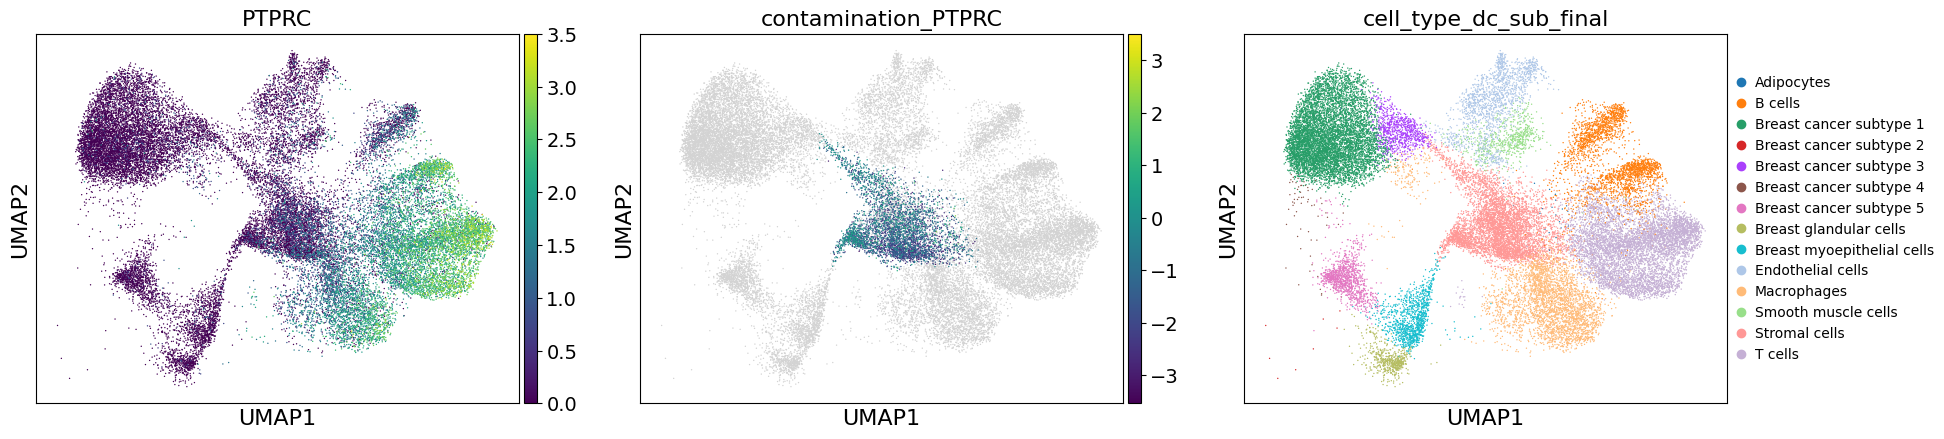

In [55]:
import scanpy as sc
sc.pl.umap(adata, color=[gene, f"contamination_{gene}", "cell_type_dc_sub_final"], vmax=3.5)

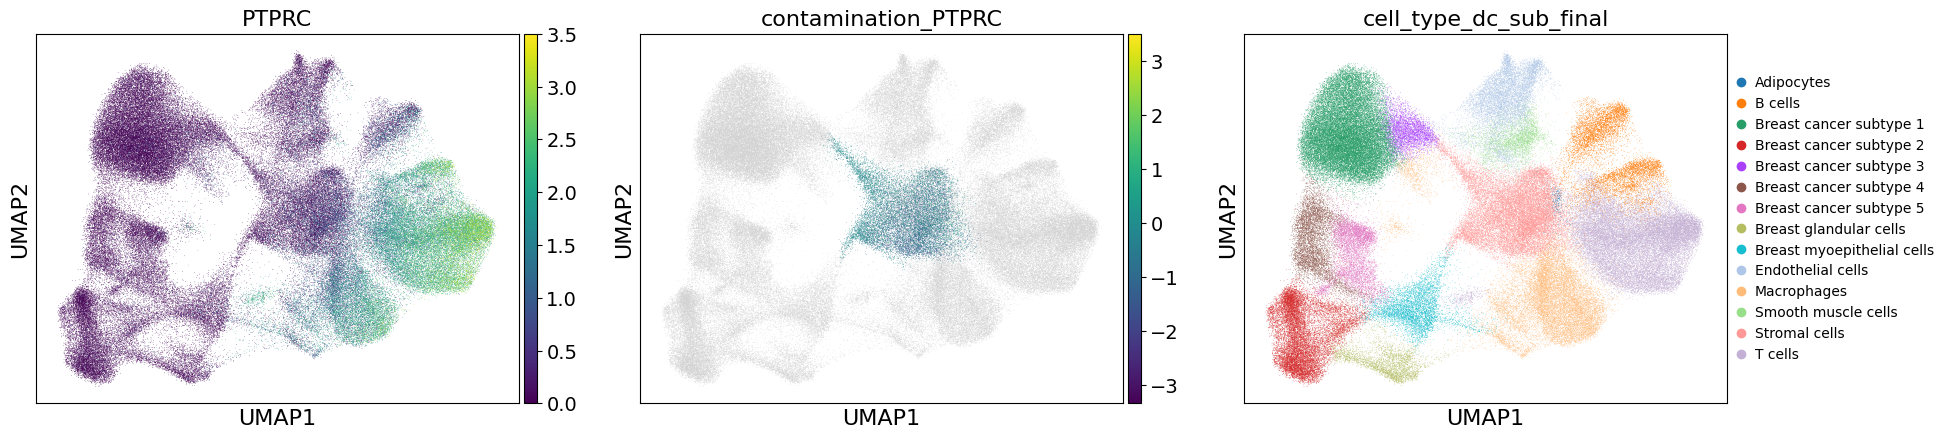

In [ ]:
import scanpy as sc
sc.pl.umap(adata, color=[gene, f"contamination_{gene}", "cell_type_dc_sub_final"], vmax=3.5)

In [48]:
results_perm

,n_target_cells,n_cells_used,n_cells_expressed,mean_target,mean_neighbor,log2foldchange,log2foldchange_unpaired,pvalue,padj,contamination_score,perm_pvalue,perm_padj,perm_mean,perm_std,perm_zscore,standardized_effect
gene,,,,,,,,,,,,,,,,
ABCC11,21022,15065,2216,0.145756,0.200001,-0.078260,-0.496715,1.196082e-69,2.053390e-69,0.318446,0.009901,0.010616,0.000422,0.003827,-20.558756,-20.558756
ACTA2,21022,15065,11534,1.306177,1.002679,0.437855,0.641619,0.000000e+00,0.000000e+00,-0.311380,0.009901,0.010616,0.007418,0.006016,71.546066,71.546066
ACTG2,21022,15065,9496,0.786381,0.893863,-0.155064,-0.273088,1.245546e-59,2.066632e-59,0.174941,0.009901,0.010616,0.003291,0.005754,-27.519626,-27.519626
ADAM9,21022,15065,8662,0.663105,0.552661,0.159337,0.350533,1.058730e-60,1.776513e-60,-0.208801,0.009901,0.010616,0.003142,0.004619,33.818587,33.818587
ADGRE5,21022,15065,3218,0.207064,0.350327,-0.206686,-0.866766,4.918876e-221,1.781593e-220,0.673104,0.009901,0.010616,-0.001273,0.003879,-52.961717,-52.961717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VWF,21022,15065,2746,0.177604,0.328967,-0.218371,-1.003070,1.458542e-220,5.156990e-220,0.786628,0.009901,0.010616,-0.000769,0.003594,-60.553163,-60.553163
WARS,21022,15065,6303,0.459855,0.445946,0.020066,0.055097,2.709525e-01,2.746515e-01,-0.035842,0.009901,0.010616,0.001422,0.004944,3.770891,3.770891
ZEB1,21022,15065,8654,0.699699,0.441720,0.372185,0.867295,0.000000e+00,0.000000e+00,-0.465406,0.009901,0.010616,0.005591,0.003611,101.518665,101.518665


In [47]:
results_perm2

,n_target_cells,n_cells_used,n_cells_expressed,mean_target,mean_neighbor_max,log2foldchange,log2foldchange_unpaired,pvalue,padj,contamination_score,perm_pvalue,perm_padj,perm_mean,perm_std,perm_zscore,standardized_effect
gene,,,,,,,,,,,,,,,,
ABCC11,5406,4136,476,0.114306,0.329603,-0.310609,-1.688875,1.629048e-93,2.506877e-93,1.449370,1.000000,1.000000,-0.395356,0.011427,7.416616,7.416616
ACTA2,5406,4136,3058,1.270871,1.582630,-0.449773,-0.593120,1.303845e-65,1.728759e-65,0.328093,1.000000,1.000000,-0.922203,0.013845,34.122426,34.122426
ACTG2,5406,4136,2597,0.779567,1.507156,-1.049689,-1.573631,0.000000e+00,0.000000e+00,1.193415,0.009901,0.017504,-0.840191,0.014292,-14.657909,-14.657909
ADAM9,5406,4136,2463,0.701301,1.125125,-0.611448,-1.033567,9.640960e-149,2.002353e-148,0.763068,1.000000,1.000000,-0.772379,0.012655,12.716908,12.716908
ADGRE5,5406,4136,890,0.209246,0.873278,-0.957995,-2.583159,0.000000e+00,0.000000e+00,3.097837,0.009901,0.017504,-0.568628,0.012707,-30.642218,-30.642218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VWF,5406,4136,554,0.127730,0.593501,-0.671966,-2.572267,4.330625e-199,1.248734e-198,2.950710,0.009901,0.017504,-0.501589,0.014437,-11.801704,-11.801704
WARS,5406,4136,1899,0.523540,1.046419,-0.754355,-1.425059,5.897244e-245,2.217065e-244,1.209793,0.831683,1.000000,-0.765243,0.010874,1.001277,1.001277
ZEB1,5406,4136,2517,0.747210,1.012241,-0.382359,-0.656814,6.071799e-61,7.874779e-61,0.451315,1.000000,1.000000,-0.649174,0.014124,18.890678,18.890678


In [49]:
from insitupy.tools.permutation import calculate_contamination_threshold

# Usage examples
print("=== CONTAMINATION THRESHOLDS ===\n")

# Get detailed info
details = calculate_contamination_threshold(
    results_perm2,
    percentile=95,
    direction="negative",
    return_details=True
)

print(f"Z-score used: {details['z_score']:.3f}")
print(f"Number of genes: {details['n_genes']}")
print(f"Gene threshold range: {details['threshold_range'][0]:.3f} to {details['threshold_range'][1]:.3f}")
print(f"Gene threshold std: {details['threshold_std']:.3f}")
print(f"Global threshold: {details['global_threshold']:.3f}")

=== CONTAMINATION THRESHOLDS ===

Z-score used: -1.645
Number of genes: 297
Gene threshold range: -0.976 to -0.024
Gene threshold std: 0.241
Global threshold: -0.477


In case of the "max" strategy, a global threshold does not make sense since the optimal threshold depends a lot on the individual genes. However, this approach is better to capture the actual contamination effects per gene.